In [1]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel, RFECV
from scipy.stats import uniform, loguniform
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from tqdm import tqdm
from sklearn.compose import TransformedTargetRegressor

In [2]:
def fit_and_evaluate(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)

    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    return r2_train, r2_test

def comparison_plot(res):
    res_sorted = res.sort_values('Test R2', ascending=False)
    df_melted = res_sorted.melt(id_vars='Model',
                                value_vars=['Train R2', 'Test R2'],
                                var_name='Metric',
                                value_name='Score')

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

    plt.title('Порівняння ефективності моделей (Train vs Test)', fontsize=16, pad=20)
    plt.ylabel('R2 Score (Коефіцієнт детермінації)', fontsize=12)
    plt.xlabel('Модель', fontsize=12)
    plt.ylim(0, 1.1)

    plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    plt.legend(title='Вибірка', loc='upper right', bbox_to_anchor=(1.15, 1))

    plt.xticks(rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

In [3]:
df = pd.read_csv("data/prepared_data.csv")
target_column = "Гострота зору некорегована далека відстань"
df = df.dropna(subset=[target_column]).reset_index(drop=True)

groups = df['Пацієнт']

x = df.drop(columns=[target_column])
y = df[target_column]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(x, y, groups=groups))

x_train = x.iloc[train_idx].copy()
x_test = x.iloc[test_idx].copy()

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

x_train.drop(columns=['Пацієнт'], inplace=True)
x_test.drop(columns=['Пацієнт'], inplace=True)

gkf = GroupKFold(n_splits=5)

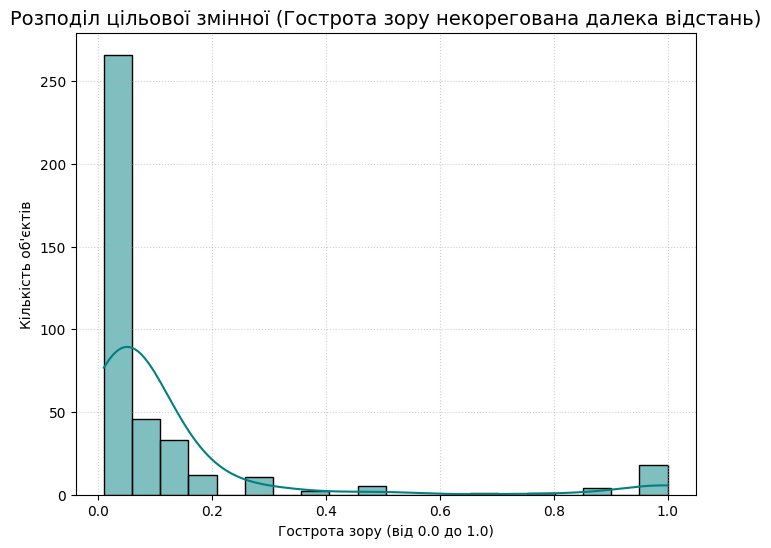

In [4]:
plt.figure(figsize=(8, 6))
sns.histplot(y, bins=20, kde=True, color='teal')
plt.title('Розподіл цільової змінної (Гострота зору некорегована далека відстань)', fontsize=14)
plt.xlabel('Гострота зору (від 0.0 до 1.0)')
plt.ylabel("Кількість об'єктів")
plt.grid(True, linestyle=':', alpha=0.6)

Аналіз розподілу цільової змінної показує, що дані не є збалансованими. Більшість об'єктів мають низьку гостроту зору, що є типовим для клінічної вибірки патологій.

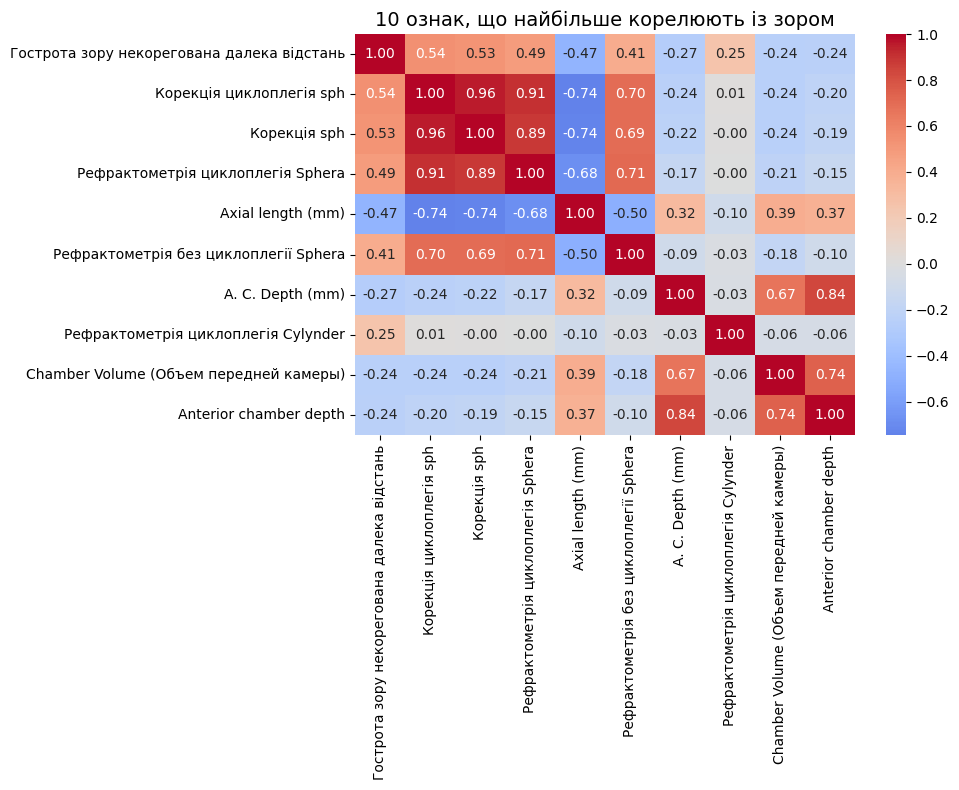

In [5]:
correlations = df.corr()[target_column].abs().sort_values(ascending=False)
top_features = correlations.head(10).index
top_corr_matrix = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('10 ознак, що найбільше корелюють із зором', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', ElasticNet(random_state=42))
])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(elastic_pipe, x_train, y_train, x_test, y_test)

print("ElasticNet:")
print(f"   Train R2: {r2_train_elastic:.4f}")
print(f"   Test R2: {r2_test_elastic:.4f}")

ElasticNet:
   Train R2: 0.0000
   Test R2: -0.0244


In [7]:
grid = {
    'model__alpha': loguniform(1e-4, 100),
    'model__l1_ratio': uniform(0, 1),
    'model__max_iter': [1000, 2000, 5000]
}

elastic_random = RandomizedSearchCV(
    estimator=elastic_pipe,
    param_distributions=grid,
    n_iter=100,
    scoring='r2',
    cv=gkf,
    verbose=1,
    random_state=42,
    return_train_score=True
)

elastic_random.fit(x_train, y_train, groups=groups_train)

best_elastic_pipe = elastic_random.best_estimator_
r2_train_elastic, r2_test_elastic = fit_and_evaluate(best_elastic_pipe, x_train, y_train, x_test, y_test)

print("ElasticNet:")
print(f"   Train R2: {r2_train_elastic:.4f}")
print(f"   Test R2: {r2_test_elastic:.4f}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits


C:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.097e+00, tolerance: 1.170e-03
  model = cd_fast.enet_coordinate_descent(
C:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.015e+00, tolerance: 1.060e-03
  model = cd_fast.enet_coordinate_descent(
C:\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.054e-01, tolerance: 1.194e-03
  model = cd_fast.enet_

ElasticNet:
   Train R2: 0.3477
   Test R2: 0.3164


In [8]:
cv_results_df = pd.DataFrame(elastic_random.cv_results_)
cv_results_df['score_diff'] = cv_results_df['mean_train_score'] - cv_results_df['mean_test_score']

columns_to_keep = ['rank_test_score', 'mean_test_score', 'mean_train_score', 'score_diff', 'params']

cv_summary = cv_results_df[columns_to_keep].sort_values(by='rank_test_score')

display(cv_summary.head(5))

,rank_test_score,mean_test_score,mean_train_score,score_diff,params
10,1,0.297068,0.361337,0.064269,"{'model__alpha': 0.01971387269004537, 'model__..."
20,2,0.296453,0.350748,0.054296,"{'model__alpha': 0.02349099519372942, 'model__..."
92,3,0.293291,0.370716,0.077425,"{'model__alpha': 0.020444965009175222, 'model_..."
0,4,0.291313,0.374198,0.082885,"{'model__alpha': 0.017670169402947963, 'model_..."
85,5,0.285830,0.363684,0.077854,"{'model__alpha': 0.09017915528354478, 'model__..."


In [9]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

r2_train_rf, r2_test_rf = fit_and_evaluate(rf_pipe, x_train, y_train, x_test, y_test)

print("Random forest:")
print(f"   Train R2: {r2_train_rf:.4f}")
print(f"   Test R2: {r2_test_rf:.4f}")

Random forest:
   Train R2: 0.9752
   Test R2: 0.8394


In [10]:
grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [None, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt', 0.5]
}

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_random = RandomizedSearchCV(estimator=rf_pipe,
                               param_distributions=grid,
                               n_iter=50,
                               cv=gkf,
                               verbose=1,
                               scoring='r2',
                               random_state=42, return_train_score=True)

rf_random.fit(x_train, y_train, groups=groups_train)
best_rf_pipe = rf_random.best_estimator_

r2_train_rf, r2_test_rf = fit_and_evaluate(best_rf_pipe, x_train, y_train, x_test, y_test)

print("Random forest:")
print(f"   Train R2: {r2_train_rf:.4f}")
print(f"   Test R2: {r2_test_rf:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Random forest:
   Train R2: 0.9824
   Test R2: 0.8591


In [11]:
cv_results_df = pd.DataFrame(rf_random.cv_results_)
cv_results_df['score_diff'] = cv_results_df['mean_train_score'] - cv_results_df['mean_test_score']

columns_to_keep = ['rank_test_score', 'mean_test_score', 'mean_train_score', 'score_diff', 'params']

cv_summary = cv_results_df[columns_to_keep].sort_values(by='rank_test_score')

display(cv_summary.head(5))

,rank_test_score,mean_test_score,mean_train_score,score_diff,params
31,1,0.752798,0.981177,0.228380,"{'model__n_estimators': 300, 'model__min_sampl..."
45,2,0.752354,0.965396,0.213042,"{'model__n_estimators': 300, 'model__min_sampl..."
12,3,0.752004,0.967270,0.215266,"{'model__n_estimators': 500, 'model__min_sampl..."
38,4,0.750856,0.979835,0.228979,"{'model__n_estimators': 500, 'model__min_sampl..."
18,5,0.750314,0.965475,0.215161,"{'model__n_estimators': 200, 'model__min_sampl..."


In [12]:
nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=20000, random_state=42))
])

r2_train_nn, r2_test_nn = fit_and_evaluate(nn_pipe, x_train, y_train, x_test, y_test)

print(f"Neural network:")
print(f"   Train R2: {r2_train_nn:.4f}")
print(f"   Val R2: {r2_test_nn:.4f}")

Neural network:
   Train R2: 0.9678
   Val R2: -0.4290


In [13]:
grid = {
    'model__hidden_layer_sizes': [(30,), (50,), (100,), (30, 15), (50, 25), (100, 50)],
    'model__activation': ['relu', 'tanh', 'logistic'],
    'model__solver': ['lbfgs', 'adam'],
    'model__alpha': loguniform(1e-5, 1e-1),
    'model__learning_rate_init': loguniform(1e-4, 1e-2)
}

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(max_iter=20000, random_state=42))
])

nn_random = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=grid,
    n_iter=50,
    scoring='r2',
    cv=gkf,
    verbose=1,
    random_state=42,
    return_train_score=True
)

nn_random.fit(x_train, y_train, groups=groups_train)

best_nn_pipe = nn_random.best_estimator_

r2_train_nn, r2_test_nn = fit_and_evaluate(best_nn_pipe, x_train, y_train, x_test, y_test)

print(f"Neural Network")
print(f"   Train R2: {r2_train_nn:.4f}")
print(f"   Test R2:   {r2_test_nn :.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Neural Network
   Train R2: 0.9983
   Test R2:   0.5052


In [14]:
cv_results_df = pd.DataFrame(nn_random.cv_results_)
cv_results_df['score_diff'] = cv_results_df['mean_train_score'] - cv_results_df['mean_test_score']

columns_to_keep = ['rank_test_score', 'mean_test_score', 'mean_train_score', 'score_diff', 'params']

cv_summary = cv_results_df[columns_to_keep].sort_values(by='rank_test_score')

display(cv_summary.head(5))

,rank_test_score,mean_test_score,mean_train_score,score_diff,params
37,1,0.506299,0.998308,0.492009,"{'model__activation': 'relu', 'model__alpha': ..."
16,2,0.436014,0.996461,0.560447,"{'model__activation': 'tanh', 'model__alpha': ..."
17,3,0.383645,0.999732,0.616087,"{'model__activation': 'relu', 'model__alpha': ..."
14,4,0.253175,0.999215,0.746040,"{'model__activation': 'tanh', 'model__alpha': ..."
31,5,0.174606,0.436354,0.261747,"{'model__activation': 'logistic', 'model__alph..."


In [15]:
cv_results_df = pd.DataFrame(elastic_random.cv_results_)
best_params = cv_results_df.loc[cv_results_df['rank_test_score'] == 2, 'params'].values[0]
print(best_params)

cv_results_df = pd.DataFrame(rf_random.cv_results_)
best_params = cv_results_df.loc[cv_results_df['rank_test_score'] == 2, 'params'].values[0]
print(best_params)

cv_results_df = pd.DataFrame(nn_random.cv_results_)
best_params = cv_results_df.loc[cv_results_df['rank_test_score'] == 1, 'params'].values[0]
print(best_params)

{'model__alpha': np.float64(0.02349099519372942), 'model__l1_ratio': np.float64(0.9266588657937942), 'model__max_iter': 5000}
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': None}
{'model__activation': 'relu', 'model__alpha': np.float64(0.08062316132568972), 'model__hidden_layer_sizes': (30, 15), 'model__learning_rate_init': np.float64(0.00012675278269816303), 'model__solver': 'lbfgs'}


In [17]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.08062, learning_rate_init=0.0001267, hidden_layer_sizes=(30, 15))

In [18]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])
elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', elastic)
])
nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(elastic_pipe, x_train, y_train, x_test, y_test)
r2_train_rf, r2_test_rf = fit_and_evaluate(rf_pipe, x_train, y_train, x_test, y_test)
r2_train_nn, r2_test_nn = fit_and_evaluate(nn_pipe, x_train, y_train, x_test, y_test)

results = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])
results.loc[0] = ['ElasticNet (136)', r2_train_elastic, r2_test_elastic]
results.loc[1] = ['Random forest (136)', r2_train_rf, r2_test_rf]
results.loc[2] = ['Neural network (136)', r2_train_nn, r2_test_nn]
results

,Model,Train R2,Test R2
0,ElasticNet (136),0.339312,0.304695
1,Random forest (136),0.965227,0.862581
2,Neural network (136),0.998444,0.503480


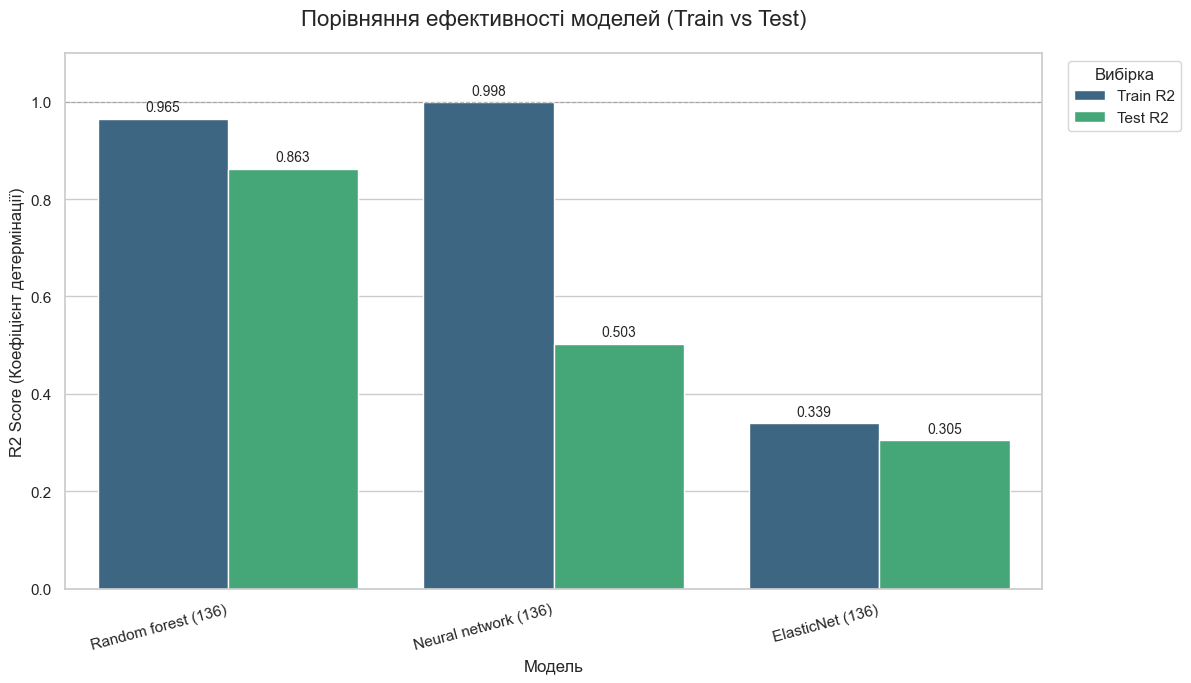

In [19]:
comparison_plot(results)

In [21]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.08062, learning_rate_init=0.0001267, hidden_layer_sizes=(30, 15))

Аналіз компонент PCA: 100%|██████████| 50/50 [04:50<00:00,  5.81s/it]


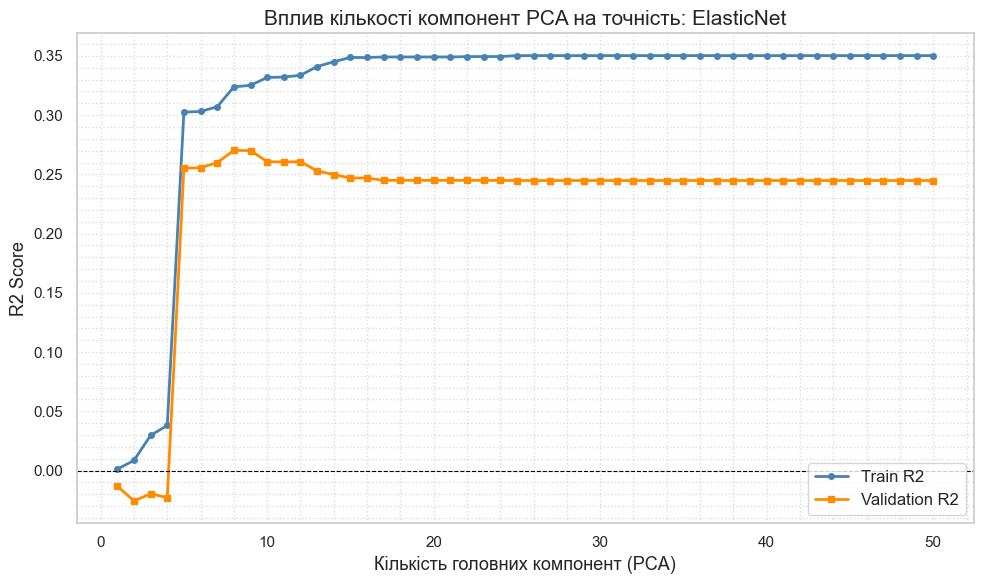

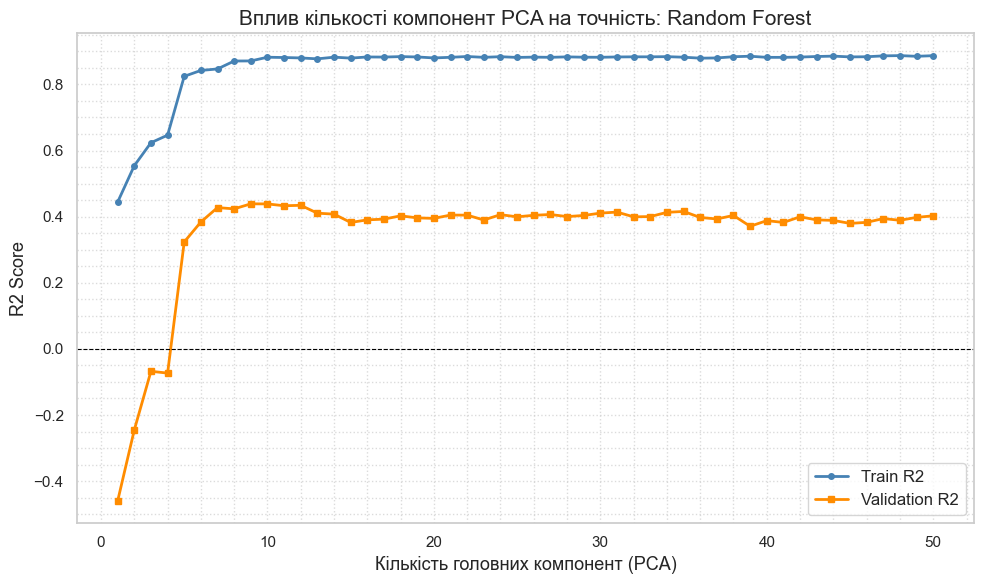

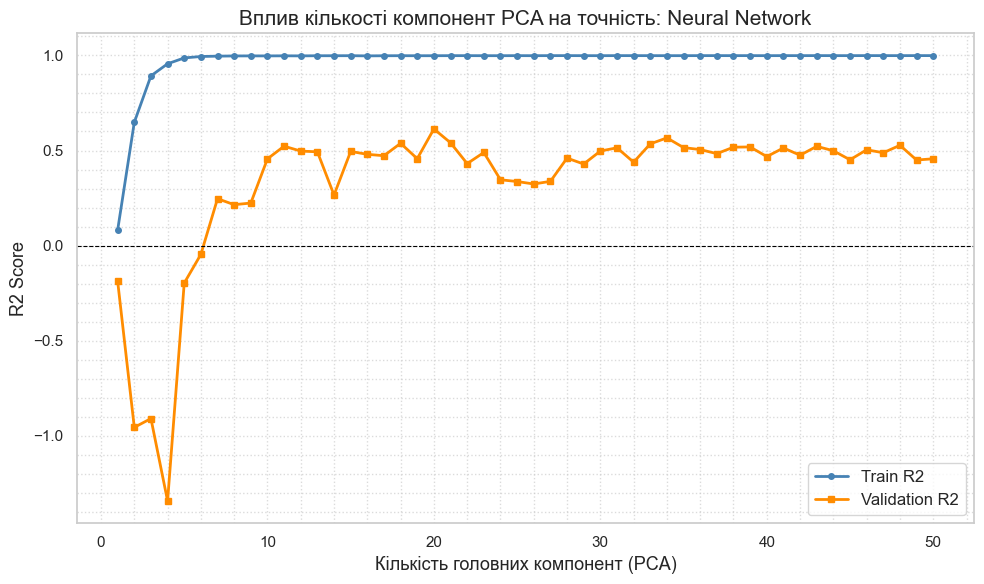

In [22]:
n_components_range = range(1, 51, 1)

scores = {
    'ElasticNet': {'train': [], 'val': []},
    'Random Forest': {'train': [], 'val': []},
    'Neural Network': {'train': [], 'val': []}
}

models = {
    'ElasticNet': elastic,
    'Random Forest': rf,
    'Neural Network': nn
}

for n in tqdm(n_components_range, desc="Аналіз компонент PCA"):

    for name, model in models.items():

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n)),
            ('model', model)
        ])

        cv_scores = cross_validate(
            estimator=pipe,
            X=x_train,
            y=y_train,
            cv=gkf,
            scoring='r2',
            return_train_score=True,
            groups=groups_train
        )

        r2_train = cv_scores['train_score'].mean()
        r2_val = cv_scores['test_score'].mean()

        scores[name]['train'].append(r2_train)
        scores[name]['val'].append(r2_val)

sns.set_theme(style="whitegrid")

for name in models.keys():
    plt.figure(figsize=(10, 6))

    plt.plot(n_components_range, scores[name]['train'],
             marker='o', markersize=4, label='Train R2', color='steelblue', linewidth=2)
    plt.plot(n_components_range, scores[name]['val'],
             marker='s', markersize=4, label='Validation R2', color='darkorange', linewidth=2)

    plt.title(f'Вплив кількості компонент PCA на точність: {name}', fontsize=15)
    plt.xlabel('Кількість головних компонент (PCA)', fontsize=13)
    plt.ylabel('R2 Score', fontsize=13)

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.minorticks_on()

    plt.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

In [23]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.08062, learning_rate_init=0.0001267, hidden_layer_sizes=(30, 15))

In [25]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=8)),
    ('model', rf)
])

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('model', elastic)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),
    ('model', nn)
])

results_pca = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic_pca, r2_test_elastic_pca = fit_and_evaluate(elastic_pipe, x_train, y_train, x_test, y_test)
r2_train_rf_pca, r2_test_rf_pca = fit_and_evaluate(rf_pipe, x_train, y_train, x_test, y_test)
r2_train_nn_pca, r2_test_nn_pca = fit_and_evaluate(nn_pipe, x_train, y_train, x_test, y_test)

results_pca.loc[0] = ['ElasticNet PCA (8)', r2_train_elastic_pca, r2_test_elastic_pca]
results_pca.loc[1] = ['Random forest PCA (10)', r2_train_rf_pca, r2_test_rf_pca]
results_pca.loc[2] = ['Neural network PCA (20)', r2_train_nn_pca, r2_test_nn_pca]

results_pca

,Model,Train R2,Test R2
0,ElasticNet PCA (8),0.324043,0.271588
1,Random forest PCA (10),0.892564,0.496158
2,Neural network PCA (20),0.997531,0.578367


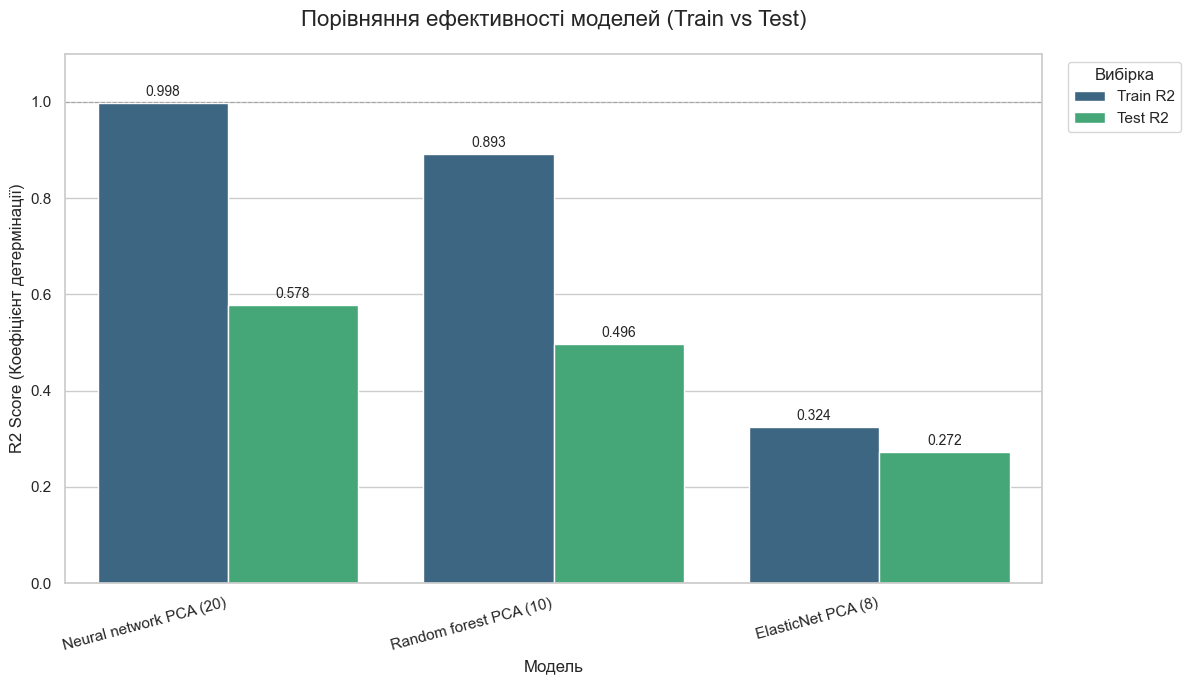

In [26]:
comparison_plot(results_pca)

Аналіз відібраних ознак: 100%|██████████| 50/50 [25:09<00:00, 30.18s/it]


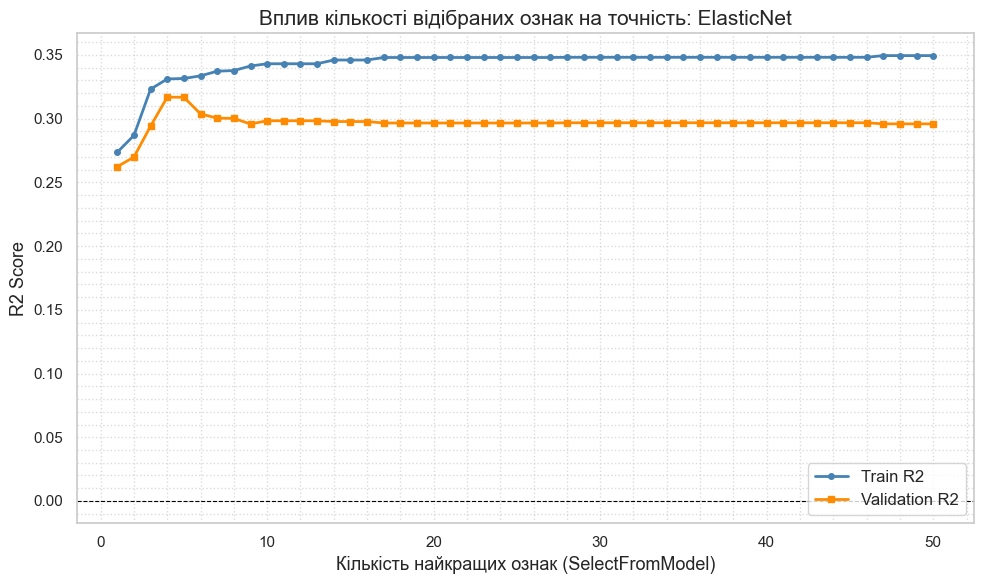

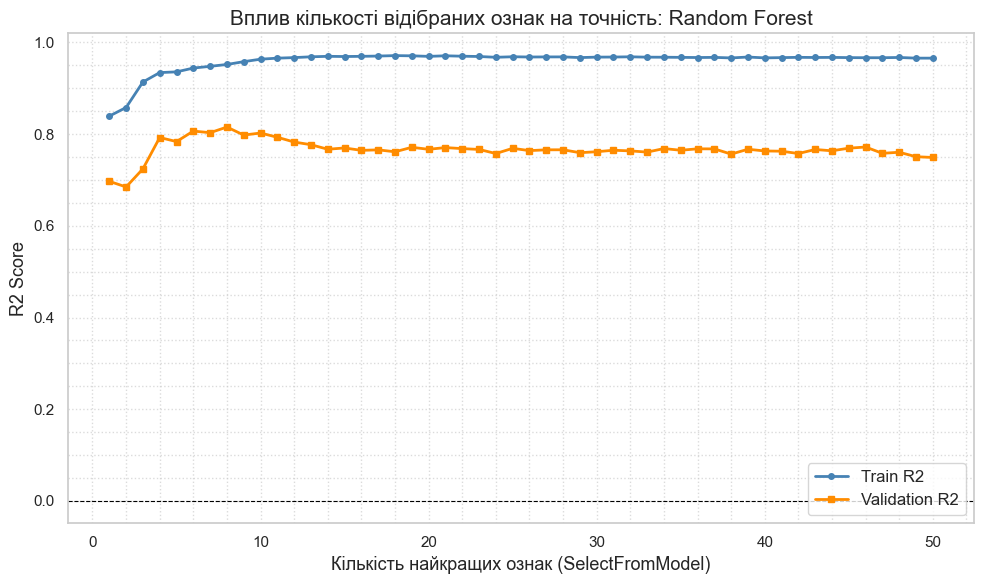

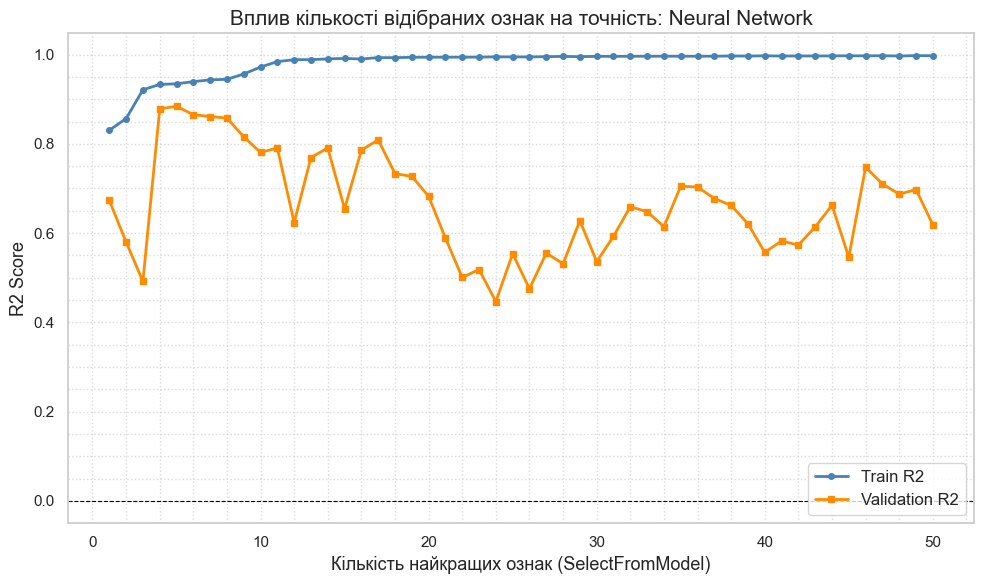

In [27]:
n_features_range = range(1, 51, 1)

scores = {
    'ElasticNet': {'train': [], 'val': []},
    'Random Forest': {'train': [], 'val': []},
    'Neural Network': {'train': [], 'val': []}
}

rf_selector = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)

models = {
    'ElasticNet': elastic,
    'Random Forest': rf,
    'Neural Network': nn
}

for n in tqdm(n_features_range, desc="Аналіз відібраних ознак"):

    for name, model in models.items():

        steps = [
            ('imputer', SimpleImputer(strategy='median'))
        ]

        if name != 'Random Forest':
            steps.append(('scaler', StandardScaler()))

        steps.append(('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=n)))

        steps.append(('model', model))

        pipe = Pipeline(steps)

        cv_scores = cross_validate(
            estimator=pipe,
            X=x_train,
            y=y_train,
            cv=gkf,
            scoring='r2',
            return_train_score=True,
            groups=groups_train
        )

        r2_train = cv_scores['train_score'].mean()
        r2_val = cv_scores['test_score'].mean()

        scores[name]['train'].append(r2_train)
        scores[name]['val'].append(r2_val)

sns.set_theme(style="whitegrid")

for name in models.keys():
    plt.figure(figsize=(10, 6))

    plt.plot(n_features_range, scores[name]['train'],
             marker='o', markersize=4, label='Train R2', color='steelblue', linewidth=2)
    plt.plot(n_features_range, scores[name]['val'],
             marker='s', markersize=4, label='Validation R2', color='darkorange', linewidth=2)

    plt.title(f'Вплив кількості відібраних ознак на точність: {name}', fontsize=15)
    plt.xlabel('Кількість найкращих ознак (SelectFromModel)', fontsize=13)
    plt.ylabel('R2 Score', fontsize=13)

    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    plt.grid(True, which='both', linestyle=':', alpha=0.7)
    plt.minorticks_on()
    plt.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

In [29]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.08062, learning_rate_init=0.0001267, hidden_layer_sizes=(30, 15))

rf_selector = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=5)),
    ('model', elastic)
])

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=8)),
    ('model', rf)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('selector', SelectFromModel(estimator=rf_selector, threshold=-np.inf, max_features=5)),
    ('model', nn)
])

In [34]:
imputer_rf = SimpleImputer(strategy='median')
x_train_imputed = pd.DataFrame(imputer_rf.fit_transform(x_train), columns=x_train.columns)

rf_selector.fit(x_train_imputed, y_train)

selector = SelectFromModel(
    rf_selector,
    threshold=-np.inf,
    max_features=10,
    prefit=True
)
selector.set_output(transform="pandas")

x_train_sel = selector.transform(x_train)
x_test_sel = selector.transform(x_test)

results_selected = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(elastic_pipe, x_train_sel, y_train, x_test_sel, y_test)
r2_train_rf, r2_test_rf = fit_and_evaluate(rf_pipe, x_train_sel, y_train, x_test_sel, y_test)
r2_train_nn, r2_test_nn = fit_and_evaluate(nn_pipe, x_train_sel, y_train, x_test_sel, y_test)

results_selected.loc[0] = ['ElasticNet Selected (5)', r2_train_elastic, r2_test_elastic]
results_selected.loc[1] = ['Random forest Selected (8)', r2_train_rf, r2_test_rf]
results_selected.loc[2] = ['Neural network Selected (5)', r2_train_nn, r2_test_nn]
results_selected

C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


,Model,Train R2,Test R2
0,ElasticNet Selected (5),0.330335,0.295372
1,Random forest Selected (8),0.966185,0.877806
2,Neural network Selected (5),0.981403,0.555733


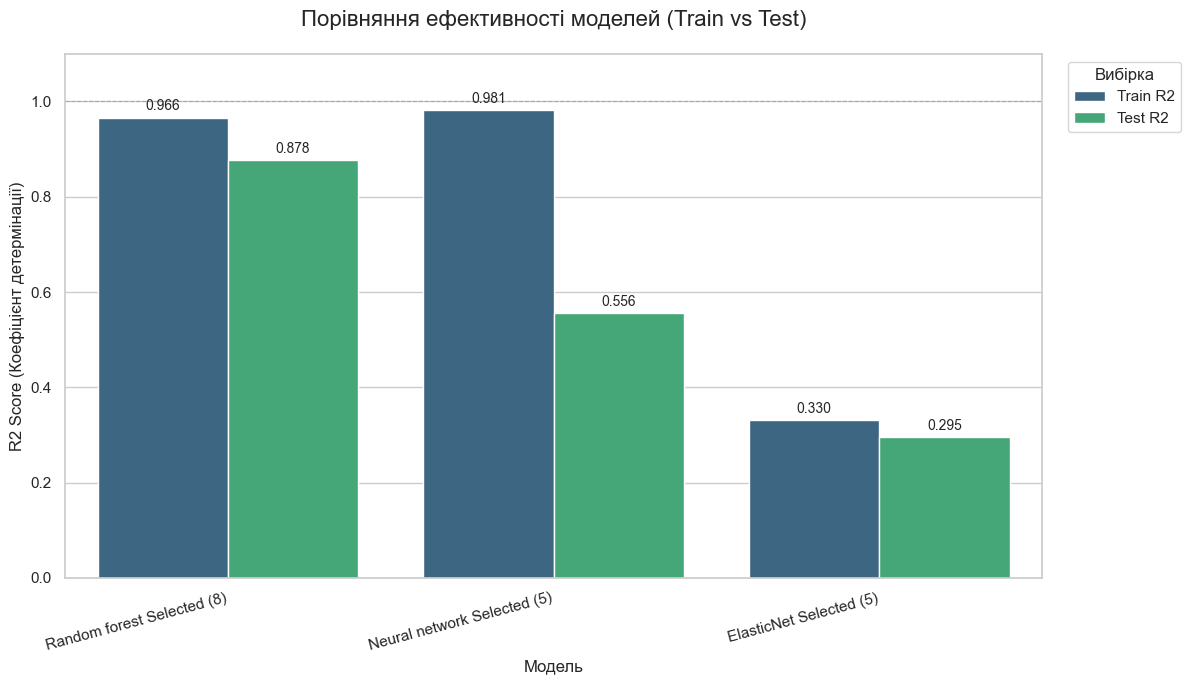

In [35]:
comparison_plot(results_selected)

In [50]:
rf_selector = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)

imputer_rfecv = SimpleImputer(strategy='median')
imputer_rfecv.set_output(transform="pandas")
x_train_imputed = imputer_rfecv.fit_transform(x_train)

rfecv = RFECV(
    estimator=rf_selector,
    step=1,
    cv=gkf,
    scoring='r2',
    min_features_to_select=5
)

rfecv.fit(x_train_imputed, y_train, groups=groups_train)

selected_features = x_train_imputed.columns[rfecv.support_]
print(f"Оптимальна кількість ознак: {rfecv.n_features_}")
print(selected_features.tolist())

Оптимальна кількість ознак: 6
['Корекція sph', 'Корекція циклоплегія sph', 'Корекція циклоплегія cyl', 'Рефрактометрія без циклоплегії Cylynder', 'Рефрактометрія циклоплегія Sphera', 'Рефрактометрія циклоплегія Cylynder']


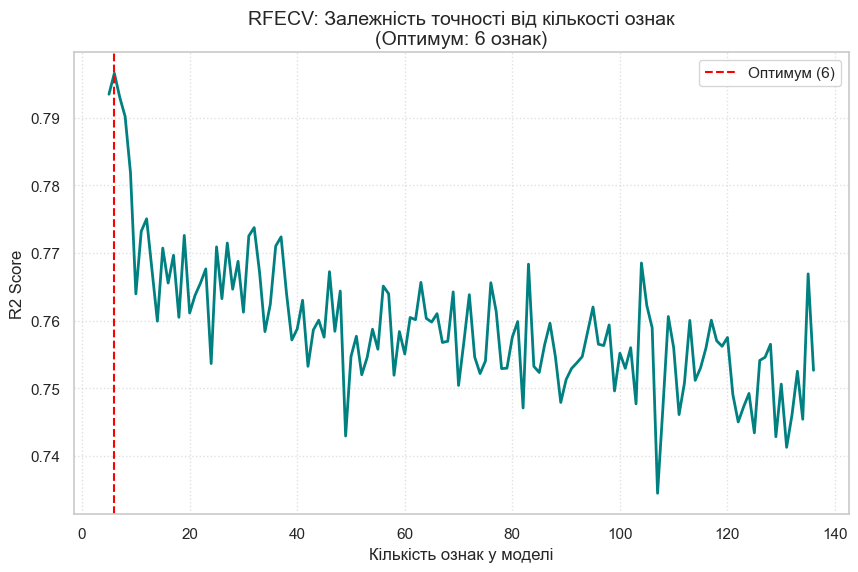

In [51]:
min_features = 5
plt.figure(figsize=(10, 6))
plt.xlabel("Кількість ознак у моделі")
plt.ylabel("R2 Score")

scores = rfecv.cv_results_['mean_test_score']
x_axis = range(min_features, len(scores) + min_features)
plt.plot(x_axis, scores, color='teal', linewidth=2)

plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Оптимум ({rfecv.n_features_})')

plt.title(f"RFECV: Залежність точності від кількості ознак\n(Оптимум: {rfecv.n_features_} ознак)", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [36]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.08062, learning_rate_init=0.0001267, hidden_layer_sizes=(30, 15))

In [52]:
features_rfe = ['Корекція sph', 'Корекція циклоплегія sph', 'Корекція циклоплегія cyl', 'Рефрактометрія без циклоплегії Cylynder', 'Рефрактометрія циклоплегія Sphera', 'Рефрактометрія циклоплегія Cylynder']

x_train_rfe = x_train.loc[:, features_rfe]
x_test_rfe = x_test.loc[:, features_rfe]
num_features = len(features_rfe)

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', elastic)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

results_rfe = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic_rfe, r2_test_elastic_rfe = fit_and_evaluate(elastic_pipe, x_train_rfe, y_train, x_test_rfe, y_test)
r2_train_rf_rfe, r2_test_rf_rfe = fit_and_evaluate(rf_pipe, x_train_rfe, y_train, x_test_rfe, y_test)
r2_train_nn_rfe, r2_test_nn_rfe = fit_and_evaluate(nn_pipe, x_train_rfe, y_train, x_test_rfe, y_test)

results_rfe.loc[0] = [f'ElasticNet RFE ({num_features})', r2_train_elastic_rfe, r2_test_elastic_rfe]
results_rfe.loc[1] = [f'Random forest RFE ({num_features})', r2_train_rf_rfe, r2_test_rf_rfe]
results_rfe.loc[2] = [f'Neural network RFE ({num_features})', r2_train_nn_rfe, r2_test_nn_rfe]

results_rfe

,Model,Train R2,Test R2
0,ElasticNet RFE (6),0.329718,0.294885
1,Random forest RFE (6),0.950633,0.863694
2,Neural network RFE (6),0.935857,0.764763


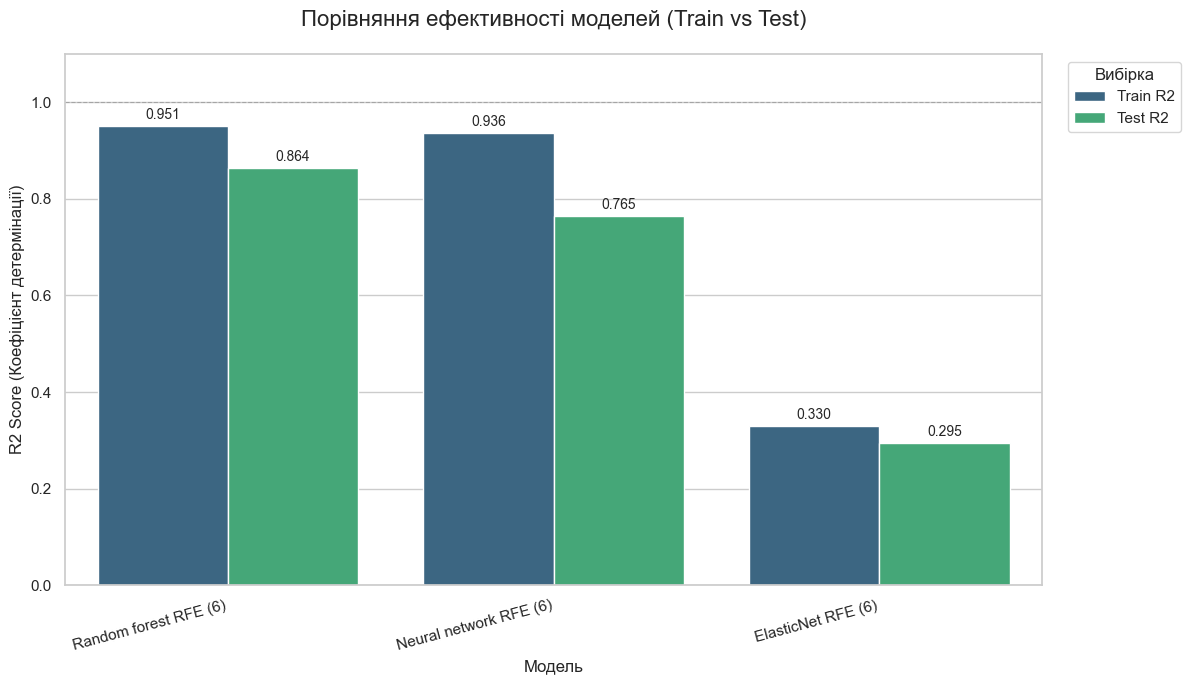

In [53]:
comparison_plot(results_rfe)

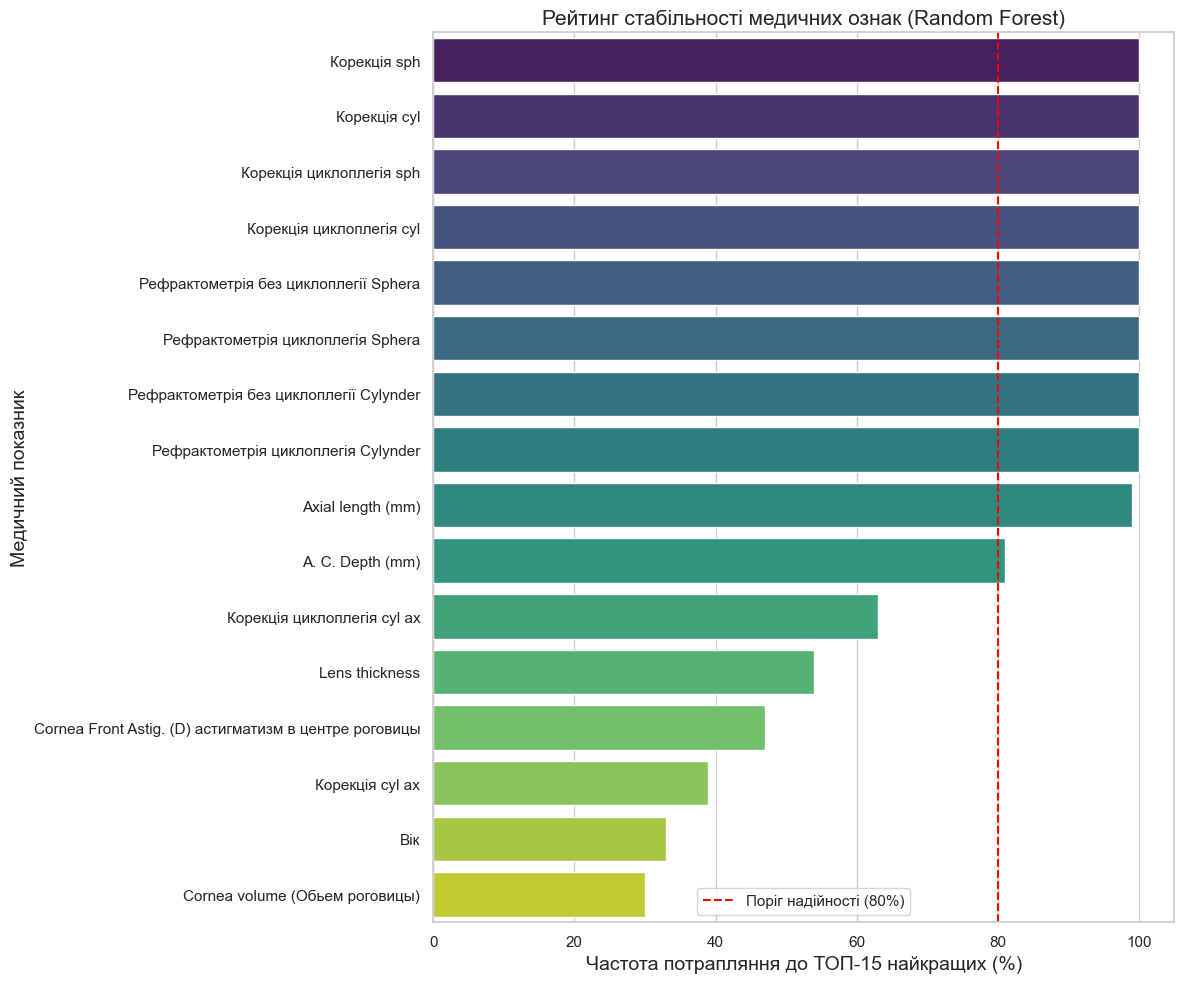

In [39]:
rf_selector = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)

feature_names = x.columns
n_iterations = 100
top_n_features = 15
feature_counter = Counter()

for i in range(n_iterations):
    x_train_split, x_test_split, y_train_split, y_test_split = train_test_split(
        x, y, test_size=0.2, random_state=i
    )

    imputer = SimpleImputer(strategy='median')
    imputer.set_output(transform="pandas")
    x_train_imputed = imputer.fit_transform(x_train_split)

    rf_selector.fit(x_train_imputed, y_train_split)

    selector = SelectFromModel(
        rf_selector,
        threshold=-np.inf,
        max_features=top_n_features,
        prefit=True
    )

    selected_indices = selector.get_support(indices=True)
    selected_names = feature_names[selected_indices]
    feature_counter.update(selected_names)

stability_df = pd.DataFrame.from_dict(feature_counter, orient='index', columns=['Кількість виборів'])
stability_df['Стабільність (%)'] = (stability_df['Кількість виборів'] / n_iterations) * 100
stability_df = stability_df.sort_values(by='Стабільність (%)', ascending=False)

plt.figure(figsize=(12, 10))
plot_data = stability_df[stability_df['Стабільність (%)'] >= 30]

sns.barplot(
    x=plot_data['Стабільність (%)'],
    y=plot_data.index,
    hue=plot_data.index,
    palette='viridis',
    legend=False
)

plt.title('Рейтинг стабільності медичних ознак (Random Forest)', fontsize=15)
plt.xlabel(f'Частота потрапляння до ТОП-{top_n_features} найкращих (%)', fontsize=14)
plt.ylabel('Медичний показник', fontsize=14)
plt.axvline(x=80, color='red', linestyle='--', label='Поріг надійності (80%)')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
stability_df

,Кількість виборів,Стабільність (%)
Корекція sph,100,100.0
Корекція cyl,100,100.0
Корекція циклоплегія sph,100,100.0
Корекція циклоплегія cyl,100,100.0
Рефрактометрія без циклоплегії Sphera,100,100.0
Рефрактометрія циклоплегія Sphera,100,100.0
Рефрактометрія без циклоплегії Cylynder,100,100.0
Рефрактометрія циклоплегія Cylynder,100,100.0
Axial length (mm),99,99.0
A. C. Depth (mm),81,81.0


In [41]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=None)
elastic = ElasticNet(random_state=42, alpha=0.02349, l1_ratio=0.9266, max_iter=5000)
nn = MLPRegressor(activation='relu', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.08062, learning_rate_init=0.0001267, hidden_layer_sizes=(30, 15))

In [42]:
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])

elastic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', elastic)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

In [43]:
stable_features = stability_df.index[:10].tolist()
x_train_stable = x_train[stable_features]
x_test_stable = x_test[stable_features]

results_stable = pd.DataFrame(columns=['Model', 'Train R2', 'Test R2'])

r2_train_elastic, r2_test_elastic = fit_and_evaluate(
    elastic_pipe, x_train_stable, y_train, x_test_stable, y_test
)
r2_train_rf, r2_test_rf = fit_and_evaluate(
    rf_pipe, x_train_stable, y_train, x_test_stable, y_test
)
r2_train_nn, r2_test_nn = fit_and_evaluate(
    nn_pipe, x_train_stable, y_train, x_test_stable, y_test
)

results_stable.loc[0] = ['ElasticNet Stable (10)', r2_train_elastic, r2_test_elastic]
results_stable.loc[1] = ['Random forest Stable (10)', r2_train_rf, r2_test_rf]
results_stable.loc[2] = ['Neural network Stable (10)', r2_train_nn, r2_test_nn]
results_stable

,Model,Train R2,Test R2
0,ElasticNet Stable (10),0.338101,0.307425
1,Random forest Stable (10),0.966238,0.872203
2,Neural network Stable (10),0.974033,0.618629


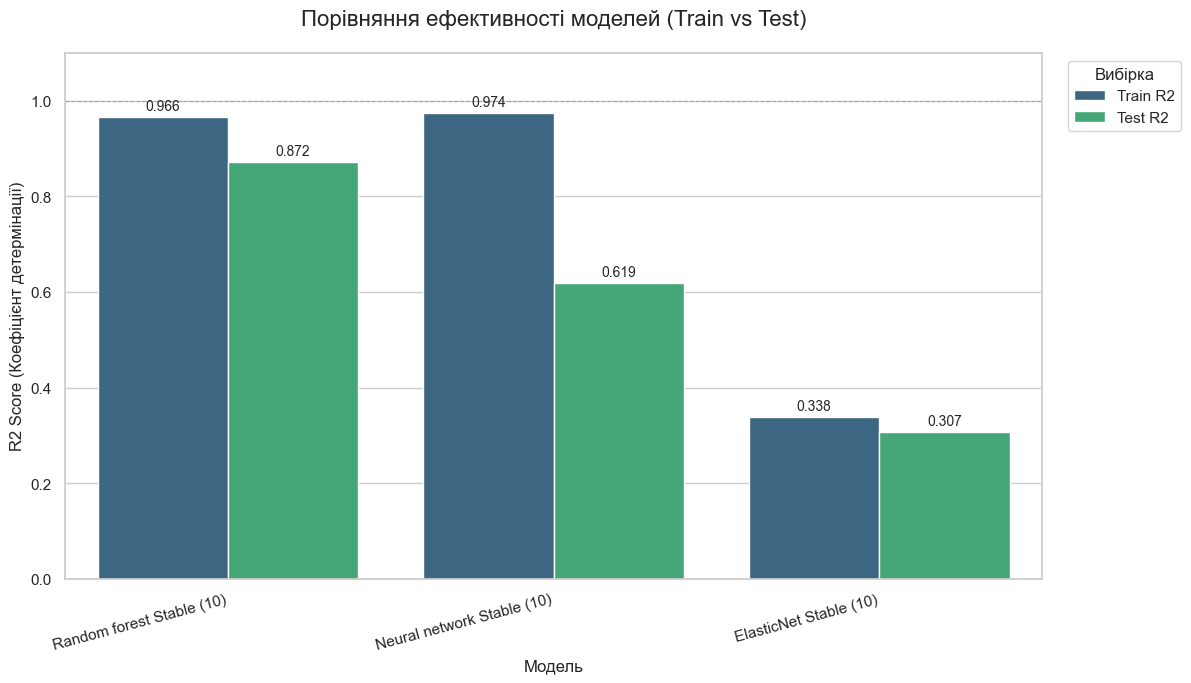

In [44]:
comparison_plot(results_stable)

In [54]:
results_full = pd.concat([results, results_pca, results_selected, results_rfe, results_stable], axis=0)
results_full['Перенавчання'] = results_full['Train R2'] - results_full['Test R2']
results_full

,Model,Train R2,Test R2,Перенавчання
0,ElasticNet (136),0.339312,0.304695,0.034617
1,Random forest (136),0.965227,0.862581,0.102646
2,Neural network (136),0.998444,0.503480,0.494963
0,ElasticNet PCA (8),0.324043,0.271588,0.052455
1,Random forest PCA (10),0.892564,0.496158,0.396406
2,Neural network PCA (20),0.997531,0.578367,0.419164
0,ElasticNet Selected (5),0.330335,0.295372,0.034963
1,Random forest Selected (8),0.966185,0.877806,0.088379
2,Neural network Selected (5),0.981403,0.555733,0.425671
0,ElasticNet RFE (6),0.329718,0.294885,0.034833


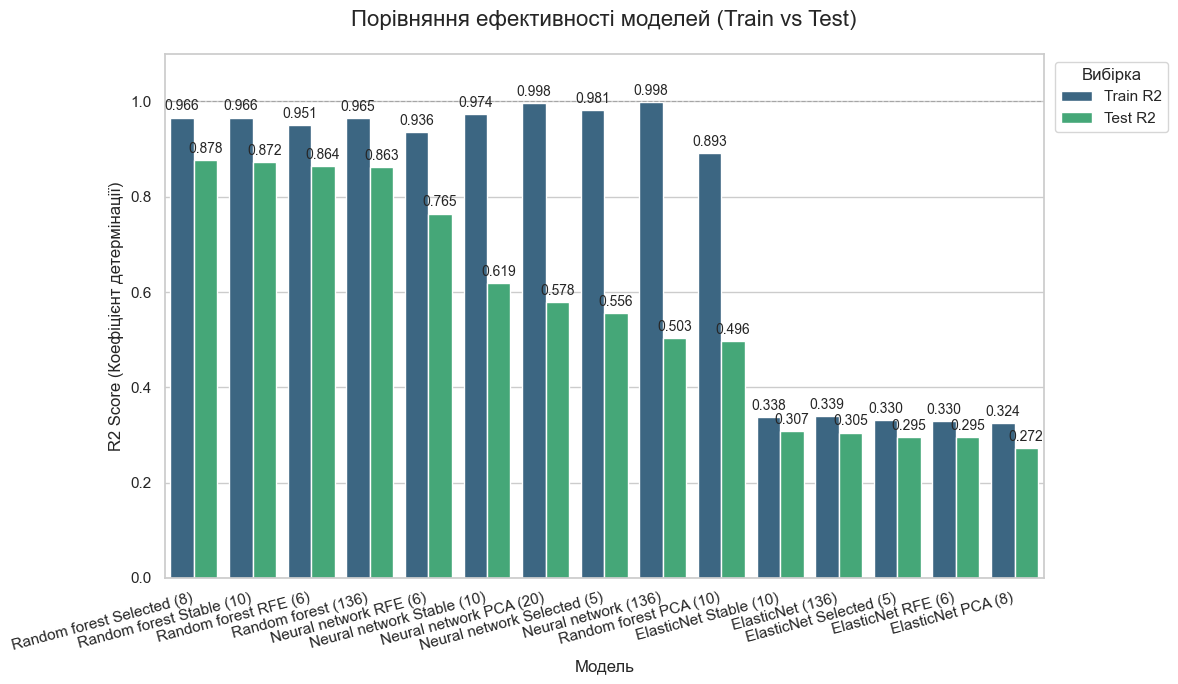

In [55]:
comparison_plot(results_full)

In [ ]:
rf = RandomForestRegressor(n_estimators=500, random_state=42, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', max_depth=10)
nn = MLPRegressor(activation='tanh', solver='lbfgs', max_iter=20000, random_state=42, alpha=0.0726, learning_rate_init=0.0012, hidden_layer_sizes=(30, 15))

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', rf)
])

nn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', nn)
])

log_target_rf_pipe = TransformedTargetRegressor(
    regressor=rf_pipe, func=np.log1p, inverse_func=np.expm1
)

log_target_nn_pipe = TransformedTargetRegressor(
    regressor=nn_pipe, func=np.log1p, inverse_func=np.expm1
)

In [ ]:
x_train_rfe = x_train.loc[:, features_rfe]
x_test_rfe = x_test.loc[:, features_rfe]

log_target_rf_pipe.fit(x_train_rfe, y_train)
y_pred_test_rf = log_target_rf_pipe.predict(x_test_rfe)

r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

log_target_nn_pipe.fit(x_train_stable, y_train)
y_pred_test_nn = nn.predict(x_test_rfe)

r2_test_nn = r2_score(y_test, y_pred_test_nn)
mae_test_nn = mean_absolute_error(y_test, y_pred_test_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))

results_test_stable = pd.DataFrame(columns=['Model', 'Test R2', 'MAE', "RMSE"])

results_test_stable.loc[0] = ['Random Forest RFE (10)', r2_test_rf, mae_test_rf, rmse_test_rf]
results_test_stable.loc[1] = ['Neural Network RFE (10)', r2_test_nn, mae_test_nn, rmse_test_nn]

In [ ]:
rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, min_samples_split=2, min_samples_leaf=2, max_features=None, max_depth=50)
rf_selector.fit(x_train_scaled, y_train)

selector = SelectFromModel(rf_selector, threshold=-np.inf, max_features=17, prefit=True)
selector.set_output(transform="pandas")

x_train_sel = selector.transform(x_train_scaled)
x_test_sel = selector.transform(x_test_scaled)

rf.fit(x_train_sel, y_train)
y_pred_test_rf = rf.predict(x_test_sel)

r2_test_rf = r2_score(y_test, y_pred_test_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

nn.fit(x_train_sel, y_train)
y_pred_test_nn = nn.predict(x_test_sel)

r2_test_nn = r2_score(y_test, y_pred_test_nn)
mae_test_nn = mean_absolute_error(y_test, y_pred_test_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_pred_test_nn))

results_test_selected = pd.DataFrame(columns=['Model', 'Test R2', 'MAE', "RMSE"])

results_test_selected.loc[0] = ['Random Forest Selected (17)', r2_test_rf, mae_test_rf, rmse_test_rf]
results_test_selected.loc[1] = ['Neural Network Selected (17)', r2_test_nn, mae_test_nn, rmse_test_nn]

In [ ]:
results_test = pd.concat([results_test_stable, results_test_selected], axis=0)
results_test

In [ ]:
res_sorted = results_test.sort_values('Test R2', ascending=False)

df_melted = res_sorted.melt(id_vars='Model',
                            value_vars=['Test R2', 'MAE', 'RMSE'],
                            var_name='Metric',
                            value_name='Score')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=11)

plt.title('Порівняння фінальних моделей на незалежній тестовій вибірці', fontsize=16, pad=20)
plt.ylabel('Значення метрики', fontsize=12)
plt.xlabel('Модель', fontsize=12)

plt.ylim(0, 1.1)

plt.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.legend(title='Метрика', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
rf.fit(x_train_stable, y_train)
y_pred_test_rf = rf.predict(x_test_stable)
residuals = y_test - y_pred_test_rf

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_test_rf, alpha=0.7, color='dodgerblue', edgecolor='k')
min_val = min(y_test.min(), y_pred_test_rf.min())
max_val = max(y_test.max(), y_pred_test_rf.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ідеальний збіг')
axes[0].set_title('Прогноз vs Реальна гострота зору', fontsize=14, pad=10)
axes[0].set_xlabel('Реальні значення (y_test)', fontsize=12)
axes[0].set_ylabel('Прогнозовані значення (y_pred)', fontsize=12)
axes[0].legend(fontsize=11)

axes[1].scatter(y_pred_test, residuals, alpha=0.7, color='darkorange', edgecolor='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2, label='Нульова помилка')
axes[1].set_title('Аналіз залишків (Residual Plot)', fontsize=14, pad=10)
axes[1].set_xlabel('Прогнозовані значення', fontsize=12)
axes[1].set_ylabel('Залишки (Реальність - Прогноз)', fontsize=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()